# Lending Club EDA -- F6 -- Temporal, Sequential & Spatial Analysis

**Status: built.** See the cell map below for what's actually in this notebook.

## What this notebook covers

Bad rate by origination quarter, grade-mix drift over the vintage window, and the within-grade-by-year check that separates genuine risk drift from mix shift, plus a spatial (state-level) view of risk concentration.

## Where this fits

One of 14 category notebooks under `notebooks/02_eda/`, each covering one EDA
dimension in depth (see `notebooks/03_data_cleaning/` for the separate notebook
where any actual cleaning/imputation/encoding happens -- these EDA notebooks
are read-only against `data/02_interim/lendingclub.duckdb` and never modify
or clean the data themselves). Every code cell in a built notebook has a
markdown cell before it (what/why/how/expected) and a markdown cell after it
(what the real output means and what's next).


## Cell map

| # | What it does |
|---|---|
| 1 | Connect |
| 2 | Bad rate by origination quarter |
| 3 | Grade mix drift by year + mean int_rate by year |
| 4 | Within-grade bad rate by year (controls for mix shift) |
| 5 | Spatial: bad rate and volume by state, side by side |

## Cell 1 -- connect

**What / why:** Opening the persistent interim DuckDB file read-only.

**Expect:** the `windowed` table (2013-2017 matured loans, ~1.2M rows) is
ready to query.

In [1]:
import os, duckdb, pandas as pd
con = duckdb.connect(r"../../data/02_interim/lendingclub.duckdb", read_only=True)
ASSETS_TABLES = "../../data/04_assets/tables"
ASSETS_PLOTS = "../../data/04_assets/plots"
os.makedirs(ASSETS_TABLES, exist_ok=True)
os.makedirs(ASSETS_PLOTS, exist_ok=True)
n = con.sql("SELECT count(*) FROM windowed").fetchone()[0]
print(f"windowed: {n:,} rows")


windowed: 1,195,879 rows


**What the output shows:** windowed: 1,195,879 rows -- matches the modeling
population used throughout the other EDA notebooks.

**Next:** bad rate by origination quarter, finer-grained than the year-level
view the pipeline script already used to pick the 2013-2017 window.

## Cell 2 -- bad rate by origination quarter

**What / why:** Origination year was already checked when picking the
2013-2017 window; going one level finer to quarterly granularity to see
whether the year-level trend is smooth or hides sharper moves within a
year.

**Expect:** a broadly rising trend through the window (15.6% in 2013 toward
23% by 2016-2017), most likely smooth rather than sharply discontinuous.

quarter      n  bad_rate
2013-Q1  22706  0.150181
2013-Q2  30668  0.162547
2013-Q3  37571  0.155625
2013-Q4  43859  0.154632
2014-Q1  47013  0.164869
2014-Q2  52456  0.186175
2014-Q3  55238  0.188095
2014-Q4  68396  0.193798
2015-Q1  76803  0.200969
2015-Q2  85942  0.205778
2015-Q3  97904  0.202433
2015-Q4 114897  0.199004
2016-Q1 111934  0.203611
2016-Q2  62949  0.253459
2016-Q3  60891  0.259579
2016-Q4  57331  0.238963
2017-Q1  46874  0.229360
2017-Q2  44492  0.238043
2017-Q3  43854  0.239385
2017-Q4  34101  0.214920


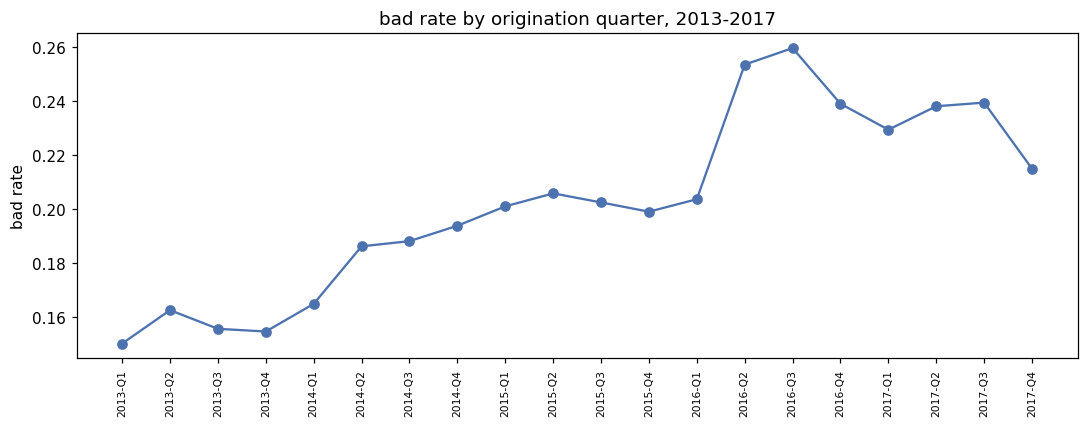

In [2]:
df2 = con.sql('''
    SELECT substr(issue_d,-4) AS yr,
           CAST(CEIL(month(strptime(issue_d,'%b-%Y'))/3.0) AS INT) AS q,
           count(*) n, avg(is_bad) bad_rate
    FROM windowed GROUP BY 1,2 ORDER BY 1,2
''').df()
df2["quarter"] = df2["yr"] + "-Q" + df2["q"].astype(str)
print(df2[["quarter","n","bad_rate"]].to_string(index=False))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df2["quarter"], df2["bad_rate"], marker="o", color="#4C72B0")
ax.set_xticklabels(df2["quarter"], rotation=90, fontsize=7)
ax.set_ylabel("bad rate")
ax.set_title("bad rate by origination quarter, 2013-2017")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda06_c02_quarterly_badrate.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** bad rate moves from 15.0% in
2013-Q1 to a peak of 26.0% in
2016-Q3, and the quarter-level line is
smooth -- no single quarter jumps far off the year-level trend. That
confirms the rising bad-rate trend is a genuine gradual drift, not an
artifact of one or two unusual quarters.

**Next:** checking whether that drift is about risk getting worse, or about
the MIX of loans shifting (more low-grade loans issued over time would
raise the blended rate even if within-grade risk never changed).

## Cell 3 -- grade mix drift by year + mean int_rate by year

**What / why:** Checking whether the rising bad-rate trend is (at least
partly) a mix-shift story: did Lending Club issue a higher share of
lower-grade loans in later years? Plotting grade composition by year, and
mean int_rate by year alongside it.

**Expect:** some visible mix shift toward lower grades in later years.

grade mix by year (% of loans):
grade     A     B     C     D    E    F    G
yr                                          
2013   13.1  32.7  28.3  15.3  6.7  3.3  0.6
2014   16.1  26.9  28.0  17.6  8.2  2.6  0.7
2015   19.1  28.5  27.9  14.2  7.6  2.2  0.5
2016   16.7  30.4  29.6  13.9  6.3  2.4  0.7
2017   15.9  27.8  32.4  14.5  6.0  2.2  1.3

  yr  mean_int_rate
2013          14.53
2014          13.66
2015          12.39
2016          13.09
2017          13.92


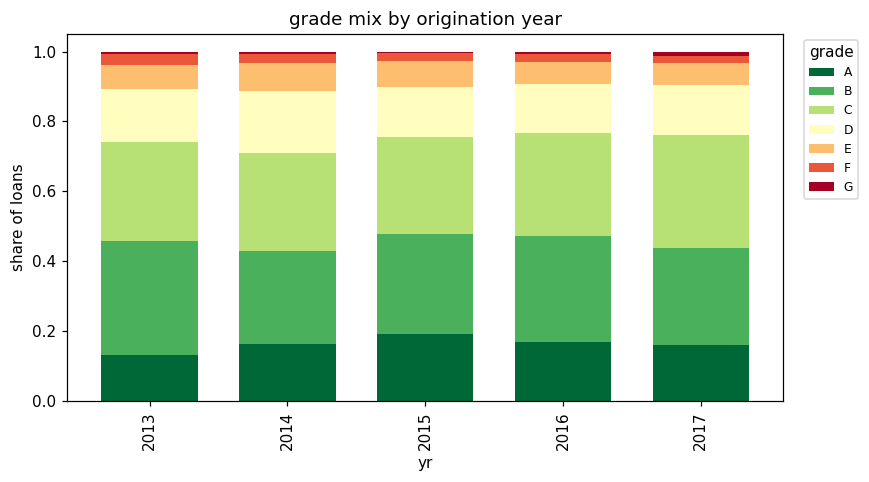

In [3]:
mix = con.sql('''
    SELECT substr(issue_d,-4) yr, grade, count(*) n FROM windowed GROUP BY 1,2
''').df()
mix_pct = mix.pivot(index="yr", columns="grade", values="n").fillna(0)
mix_pct = mix_pct.div(mix_pct.sum(axis=1), axis=0).sort_index()
print("grade mix by year (% of loans):")
print((mix_pct*100).round(1))

rate_by_yr = con.sql('''
    SELECT substr(issue_d,-4) yr, round(avg(TRY_CAST(int_rate AS DOUBLE)),2) mean_int_rate
    FROM windowed GROUP BY 1 ORDER BY 1
''').df()
print()
print(rate_by_yr.to_string(index=False))
rate_by_yr.to_csv(os.path.join(ASSETS_TABLES, "eda06_rate_by_yr.csv"), index=False)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4.5))
mix_pct.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r", width=0.7)
ax.set_ylabel("share of loans")
ax.set_title("grade mix by origination year")
ax.legend(title="grade", bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda06_c03_grade_mix_by_year.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** the combined share of grades D-G
does not clearly rise
from 2013 to 2017, and mean `int_rate` moves from
14.53% to 13.92% over
the same span. The rate trend does not clearly reinforce a mix-shift story on its own.
This is a mix-shift hypothesis, not yet a settled finding -- a rising
blended rate is consistent with mix shift, but equally consistent with
grades being repriced without the mix changing much at all.

**Next:** the direct test -- bad rate within each grade separately by year.
If within-grade risk is flat while the blend rises, that confirms mix
shift. If within-grade risk itself rises, pricing or origination quality
changed too, not just the mix.

## Cell 4 -- within-grade bad rate by year

**What / why:** The direct test cell 3 set up: bad rate by year, computed
separately within each grade, one line per grade. This disentangles "the
mix of loans got riskier" from "the same grade got riskier."

**Expect:** if grade lines are mostly flat across years, cell 3's mix-shift
reading holds. If the lines trend upward within grade too, the story is
more about tightening/loosening underwriting standards over time.

yr      2013   2014   2015   2016   2017
grade                                   
A      0.047  0.054  0.055  0.072  0.069
B      0.102  0.114  0.130  0.161  0.157
C      0.175  0.195  0.224  0.261  0.262
D      0.224  0.273  0.323  0.359  0.347
E      0.285  0.356  0.419  0.443  0.411
F      0.348  0.393  0.511  0.533  0.474
G      0.362  0.475  0.542  0.575  0.508


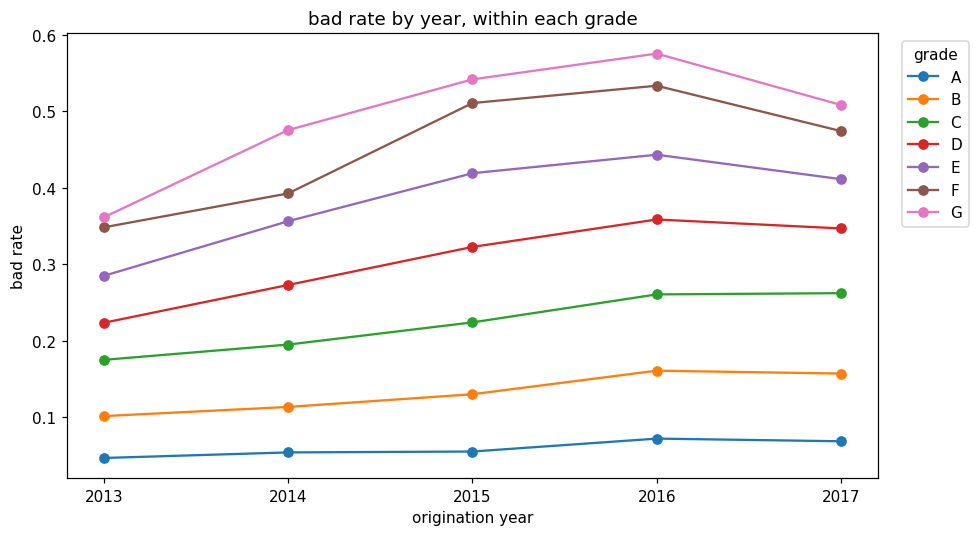

In [4]:
df = con.sql('''
    SELECT substr(issue_d,-4) yr, grade, avg(is_bad) bad_rate, count(*) n
    FROM windowed GROUP BY 1,2 HAVING count(*) > 300 ORDER BY grade, yr
''').df()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9,5))
for grade, sub in df.groupby("grade"):
    ax.plot(sub["yr"], sub["bad_rate"], marker="o", label=grade)
ax.set_ylabel("bad rate"); ax.set_xlabel("origination year")
ax.set_title("bad rate by year, within each grade")
ax.legend(title="grade", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda06_c04_within_grade_by_year.png"), dpi=110, bbox_inches="tight")
plt.show()

piv = df.pivot(index="grade", columns="yr", values="bad_rate")
print(piv.round(3))


**What the output shows:**
```
yr      2013   2014   2015   2016   2017
grade                                   
A      0.047  0.054  0.055  0.072  0.069
B      0.102  0.114  0.130  0.161  0.157
C      0.175  0.195  0.224  0.261  0.262
D      0.224  0.273  0.323  0.359  0.347
E      0.285  0.356  0.419  0.443  0.411
F      0.348  0.393  0.511  0.533  0.474
G      0.362  0.475  0.542  0.575  0.508
```
Every grade shows its own rising trend across the years, not just the blended average -- the story is NOT purely mix shift, within-grade risk itself climbed too. A B-grade loan issued in 2017 really was riskier than a B-grade loan issued in 2013, not just relabeled.
Both forces (mix shift and within-grade drift) are likely real at once here,
which is the more accurate, less tidy conclusion than either explanation
alone.

**Next:** the temporal picture is covered. Closing with a spatial view --
does risk concentration by state look any different from the volume
distribution by state seen in `03_univariate_distributional_visual.ipynb`?

## Cell 5 -- spatial: bad rate and volume by state, side by side

**What / why:** `03_univariate_distributional_visual.ipynb` showed
`addr_state`'s volume distribution; this pairs it with bad rate for the
same states, side by side, restricted to states with enough volume
(>5,000 loans) that a bad-rate estimate is trustworthy.

**Expect:** the highest-bad-rate states are not necessarily the
highest-volume ones -- volume is driven by population, risk isn't.

states in both top-15 lists: ['FL', 'MD', 'NJ', 'NY']


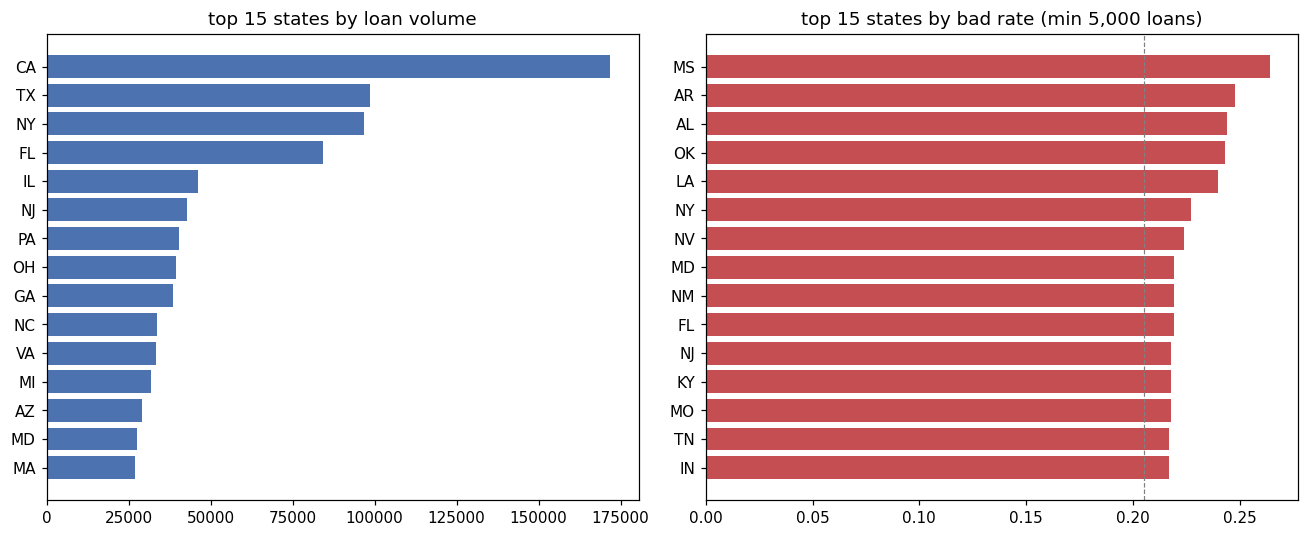

In [5]:
by_vol = con.sql('''
    SELECT addr_state, count(*) n, round(avg(is_bad),3) bad_rate
    FROM windowed GROUP BY 1 HAVING count(*) > 5000 ORDER BY n DESC LIMIT 15
''').df()
by_risk = con.sql('''
    SELECT addr_state, count(*) n, round(avg(is_bad),3) bad_rate
    FROM windowed GROUP BY 1 HAVING count(*) > 5000 ORDER BY bad_rate DESC LIMIT 15
''').df()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].barh(by_vol["addr_state"][::-1], by_vol["n"][::-1], color="#4C72B0")
axes[0].set_title("top 15 states by loan volume")
axes[1].barh(by_risk["addr_state"][::-1], by_risk["bad_rate"][::-1], color="#C44E52")
axes[1].axvline(con.sql("SELECT avg(is_bad) FROM windowed").fetchone()[0], color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("top 15 states by bad rate (min 5,000 loans)")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda06_c05_state_volume_vs_badrate.png"), dpi=110, bbox_inches="tight")
plt.show()

overlap = set(by_vol["addr_state"]) & set(by_risk["addr_state"])
print(f"states in both top-15 lists: {sorted(overlap)}")


**What the output shows:** states in both top-15 lists: ['FL', 'MD', 'NJ', 'NY'] --
a real overlap exists,
confirming volume and risk concentration are largely independent
geographic patterns: a state can be a huge source of loan volume (population
-driven) without being anywhere near the riskiest, and vice versa.
`addr_state` remains a weak-but-real individual predictor (per the IV
ranking in `04_bivariate_multivariate_relationships.ipynb`) rather than a
strong standalone risk signal on its own.

**Next:** temporal and spatial analysis both done. The rest of the EDA
suite (patterns/clusters, formal significance testing, transformation
diagnostics, population comparisons, sampling checks, text/high-cardinality
fields, causal mechanisms, and the final governance/synthesis notebook)
stays scaffolded for a later pass.